# 24 — Regional rock-abundance map (circum-Chryse)

Documentation + analysis for [PLAN_RegionalMap.md](../PLAN_RegionalMap.md): the first
real **regional deployment** of the frozen head + Stage-1 `CalibrationLayer`, tested
against the boulder-rich Late-Hesperian tsunami deposits of
[Rodriguez et al. 2016, *Sci. Rep.* 6:25106](https://doi.org/10.1038/srep25106) and
independent **THEMIS / TES thermal inertia**.

**This notebook, §1:** *what region are we mapping?* It draws the inference block that
`scripts/map_region.py --all` runs on Sherlock — the **7 contiguous Murray Lab CTX
tiles** (`E0_N40, E4_N40, E4_N44, E8_N40, E8_N44, E12_N44, E16_N44`) over the eastern
circum-Chryse / NW Arabia Terra highland-lowland boundary — with the cohort HiRISE
footprints that train/anchor the model overlaid. The key realisation (PLAN §0): ~21
boulder-rich cohort images sit **on this boundary**, and the paper's Fig-2C image
**ESP_017355_2260** *is* a cohort image, so the region is in-distribution where we lead
and OOD in the distal plains where we stress-test.

Later sections (filled once the Sherlock run returns GeoTIFFs to `reports/map_region/`):
the calibrated abundance mosaic, abundance↔thermal-inertia correlation, the
shoreline-distance profile, the cohort truth-anchor, and the OOD-honesty panel.


In [1]:
import sys
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

REPO = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src").exists())
sys.path.insert(0, str(REPO))
FIG = REPO / "reports" / "figures"; FIG.mkdir(parents=True, exist_ok=True)

# The 7-tile inference block (must match scripts/map_region.BLOCK_TILES).
BLOCK_TILES = ["E0_N40", "E4_N40", "E4_N44", "E8_N40", "E8_N44", "E12_N44", "E16_N44"]
TILE_DEG = 4  # Murray Lab tiles are 4 deg x 4 deg

def tile_to_box(name):
    """Murray tile id 'E16_N44' / 'W008_N32' -> (lon0, lat0) lower-left corner in deg."""
    e, n = name.split("_")
    lon = int(e[1:]) * (1 if e[0] == "E" else -1)
    lat = int(n[1:]) * (1 if n[0] == "N" else -1)
    return lon, lat

boxes = {t: tile_to_box(t) for t in BLOCK_TILES}
lons = [lo for lo, _ in boxes.values()]; lats = [la for _, la in boxes.values()]
block_extent = (min(lons), max(lons) + TILE_DEG, min(lats), max(lats) + TILE_DEG)
print("block tiles:", BLOCK_TILES)
print("block extent  lon[%g, %g]  lat[%g, %g] deg" % block_extent)
print("block area ~ %d tiles x (4 deg)^2; full-res S=32 ~ 15.4M tiles" % len(BLOCK_TILES))

block tiles: ['E0_N40', 'E4_N40', 'E4_N44', 'E8_N40', 'E8_N44', 'E12_N44', 'E16_N44']
block extent  lon[0, 20]  lat[40, 48] deg
block area ~ 7 tiles x (4 deg)^2; full-res S=32 ~ 15.4M tiles


In [2]:
# Cohort HiRISE footprints (centres) + rich/poor label.
cohort = pd.read_csv(REPO / "hirise_40_vclaire.csv")
cohort = cohort[["ObsId", "BoulderLabel", "CenterLat", "CenterLon_180"]].copy()
COL = {"Boulder rich": "#d62728", "Boulder poor": "#1f77b4", "unknown": "0.55"}
cohort["color"] = cohort.BoulderLabel.map(COL).fillna("0.55")

lo0, lo1, la0, la1 = block_extent
in_block = cohort[(cohort.CenterLon_180.between(lo0, lo1)) & (cohort.CenterLat.between(la0, la1))]
print("cohort total:", len(cohort))
print("cohort within the 7-tile block:", len(in_block))
print(in_block.BoulderLabel.value_counts().to_string())
PAPER_IMG = "ESP_017355_2260"  # Rodriguez+2016 Fig 2C; in our cohort
print("paper Fig-2C image in cohort:", PAPER_IMG in set(cohort.ObsId))

cohort total: 39
cohort within the 7-tile block: 21
BoulderLabel
Boulder rich    20
unknown          1
paper Fig-2C image in cohort: True


wrote reports\figures\24_region_extent.png


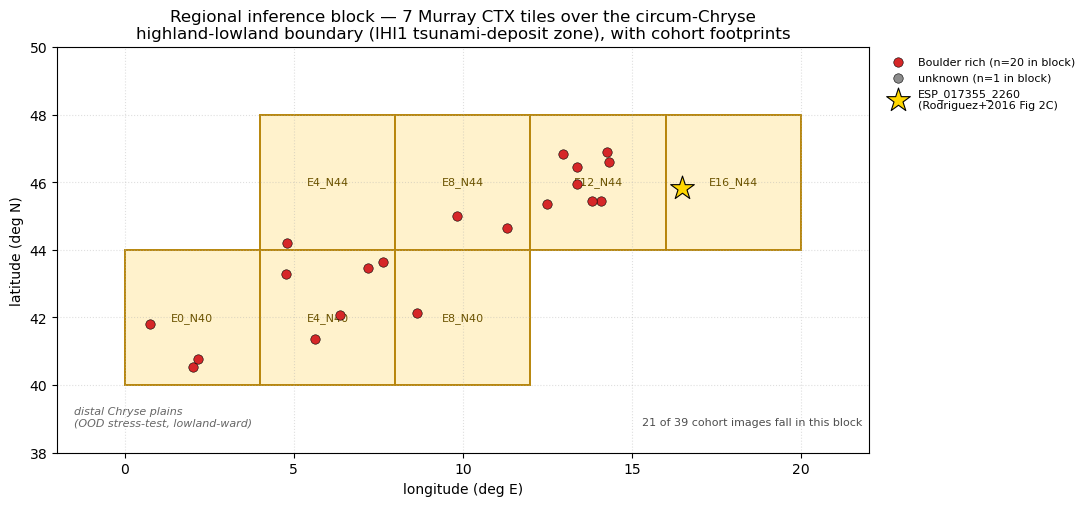

In [3]:
fig, ax = plt.subplots(figsize=(11, 6.2))

# 1) the 7 Murray tiles = the inference block.
for t, (lo, la) in boxes.items():
    ax.add_patch(Rectangle((lo, la), TILE_DEG, TILE_DEG, facecolor="#fff2cc",
                           edgecolor="#b8860b", lw=1.4, zorder=1))
    ax.text(lo + TILE_DEG / 2, la + TILE_DEG / 2, t, ha="center", va="center",
            fontsize=8, color="#6b5300", zorder=2)

# 2) cohort footprints WITHIN the block, coloured by label (count only what's drawn).
for lab, c in COL.items():
    sub = in_block[in_block.BoulderLabel == lab]
    if len(sub):
        ax.scatter(sub.CenterLon_180, sub.CenterLat, s=46, c=c, edgecolor="k",
                   lw=0.4, label=f"{lab} (n={len(sub)} in block)", zorder=4)

# 3) the paper's Fig-2C image — the parity / truth-anchor site.
pi = cohort[cohort.ObsId == PAPER_IMG]
if len(pi):
    ax.scatter(pi.CenterLon_180, pi.CenterLat, s=320, marker="*",
               facecolor="gold", edgecolor="k", lw=0.8, zorder=5,
               label=f"{PAPER_IMG}\n(Rodriguez+2016 Fig 2C)")

ax.set_xlim(lo0 - 2, lo1 + 2); ax.set_ylim(la0 - 2, la1 + 2)
ax.set_xlabel("longitude (deg E)"); ax.set_ylabel("latitude (deg N)")
ax.set_title("Regional inference block — 7 Murray CTX tiles over the circum-Chryse\n"
             "highland-lowland boundary (lHl1 tsunami-deposit zone), with cohort footprints")
ax.grid(True, ls=":", alpha=0.4); ax.set_aspect("equal")
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1.0), fontsize=8, frameon=False)
ax.annotate("distal Chryse plains\n(OOD stress-test, lowland-ward)", (lo0 - 1.5, la0 - 1.2),
            fontsize=8, style="italic", color="0.4")
ax.annotate(f"{len(in_block)} of {len(cohort)} cohort images fall in this block",
            (lo1 + 1.8, la0 - 1.2), ha="right", fontsize=8, color="0.3")
fig.tight_layout()
out = FIG / "24_region_extent.png"; fig.savefig(out, dpi=140, bbox_inches="tight")
print("wrote", out.relative_to(REPO)); plt.show()

## 2. Stitched regional abundance mosaic

`scripts/map_region.py --all` writes per Murray tile `<tile>_{prob,abundance,prob_raw}.tif`
(160 m/px) to `reports/map_region/`. All 7 share the Murray `clon_0` equirectangular CRS, so
`src.mapping.mosaic_geotiffs` merges them into **one** georeferenced raster — no reprojection;
the block is an L-shape so the two missing corners are nodata. Below is the calibrated
`fractional_area` abundance with the cohort footprints overlaid: high-abundance terrain should
track the boulder-rich cohort sites along the highland–lowland boundary (the qualitative form
of validation leg 4, ahead of the quantitative legs in §3).


wrote reports\figures\24_region_mosaic.png + reports\map_region\regional_abundance_mosaic.tif


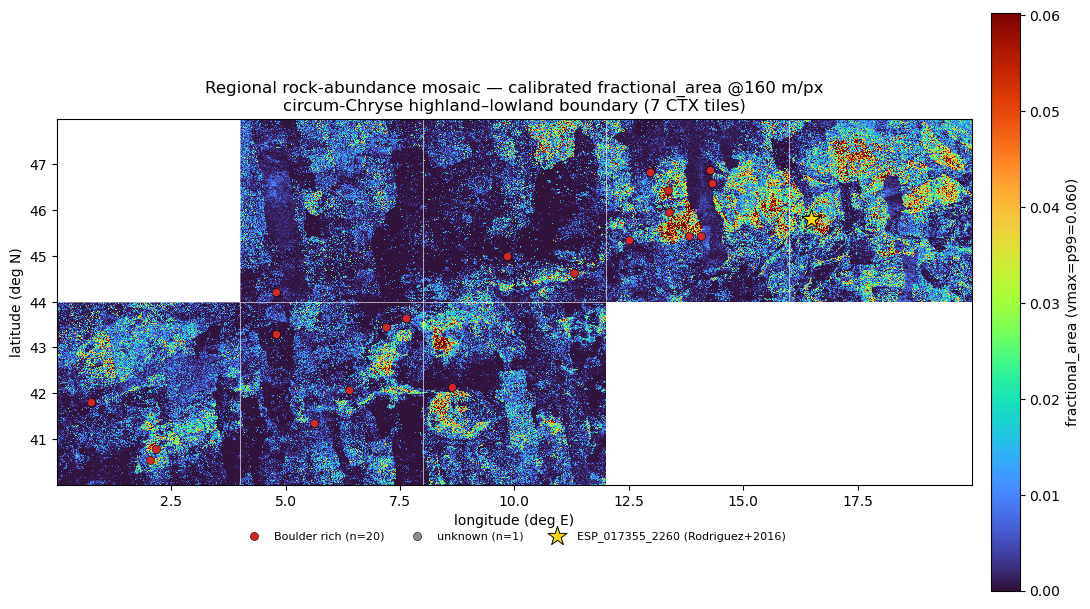

In [4]:
import math
from src.mapping import mosaic_geotiffs
MAP_DIR = REPO / "reports" / "map_region"
ab_tifs = sorted(MAP_DIR.glob("*_abundance.tif")) if MAP_DIR.exists() else []
if not ab_tifs:
    print("No abundance GeoTIFFs yet under reports/map_region/.")
    print("Run on Sherlock:  python scripts/map_region.py --all  -> download *.tif into reports/map_region/.")
else:
    arr, transform, _ = mosaic_geotiffs(ab_tifs, MAP_DIR / "regional_abundance_mosaic.tif")
    R = 3396190.0; dpm = 180.0 / (math.pi * R)   # clon_0 equirectangular metres -> degrees
    h, w = arr.shape
    left, top = transform.c, transform.f
    right, bottom = left + w * transform.a, top + h * transform.e
    ext = [left * dpm, right * dpm, bottom * dpm, top * dpm]   # lon0, lon1, lat0, lat1
    vmax = float(np.nanpercentile(arr, 99)) or 1e-3

    fig, ax = plt.subplots(figsize=(11, 6.6))
    im = ax.imshow(np.ma.masked_invalid(arr), cmap="turbo", vmin=0, vmax=vmax, extent=ext,
                   origin="upper", interpolation="nearest", aspect="equal")
    for t, (lo, la) in boxes.items():                      # tile outlines
        ax.add_patch(Rectangle((lo, la), TILE_DEG, TILE_DEG, fill=False,
                               edgecolor="white", lw=0.6, alpha=0.45))
    for lab, c in COL.items():                             # cohort footprints
        sub = in_block[in_block.BoulderLabel == lab]
        if len(sub):
            ax.scatter(sub.CenterLon_180, sub.CenterLat, s=34, c=c, edgecolor="k", lw=0.4,
                       label=f"{lab} (n={len(sub)})", zorder=4)
    pi = cohort[cohort.ObsId == PAPER_IMG]
    if len(pi):
        ax.scatter(pi.CenterLon_180, pi.CenterLat, s=210, marker="*", facecolor="gold",
                   edgecolor="k", lw=0.7, zorder=5, label=f"{PAPER_IMG} (Rodriguez+2016)")
    ax.set_xlim(ext[0], ext[1]); ax.set_ylim(ext[2], ext[3])
    ax.set_xlabel("longitude (deg E)"); ax.set_ylabel("latitude (deg N)")
    ax.set_title("Regional rock-abundance mosaic — calibrated fractional_area @160 m/px\n"
                 "circum-Chryse highland–lowland boundary (7 CTX tiles)")
    fig.colorbar(im, ax=ax, fraction=0.030, pad=0.02, label=f"fractional_area (vmax=p99={vmax:.3f})")
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.10), ncol=4, fontsize=8, frameon=False)
    fig.tight_layout()
    out = FIG / "24_region_mosaic.png"; fig.savefig(out, dpi=150, bbox_inches="tight")
    print("wrote", out.relative_to(REPO), "+", (MAP_DIR / "regional_abundance_mosaic.tif").relative_to(REPO))
    plt.show()

### 2b. All three products side by side

The same stitch applied to the **calibrated P(boulder-rich)** tiles, plus the **binary
rich/poor** map (threshold P ≥ 0.5). Abundance (continuous regression target) and
probability (the classifier) carry the same spatial structure; the binary panel is what a
"where are the boulder fields" map looks like. Boulder-rich cohort sites in cyan.


wrote reports\figures\24_region_products.png


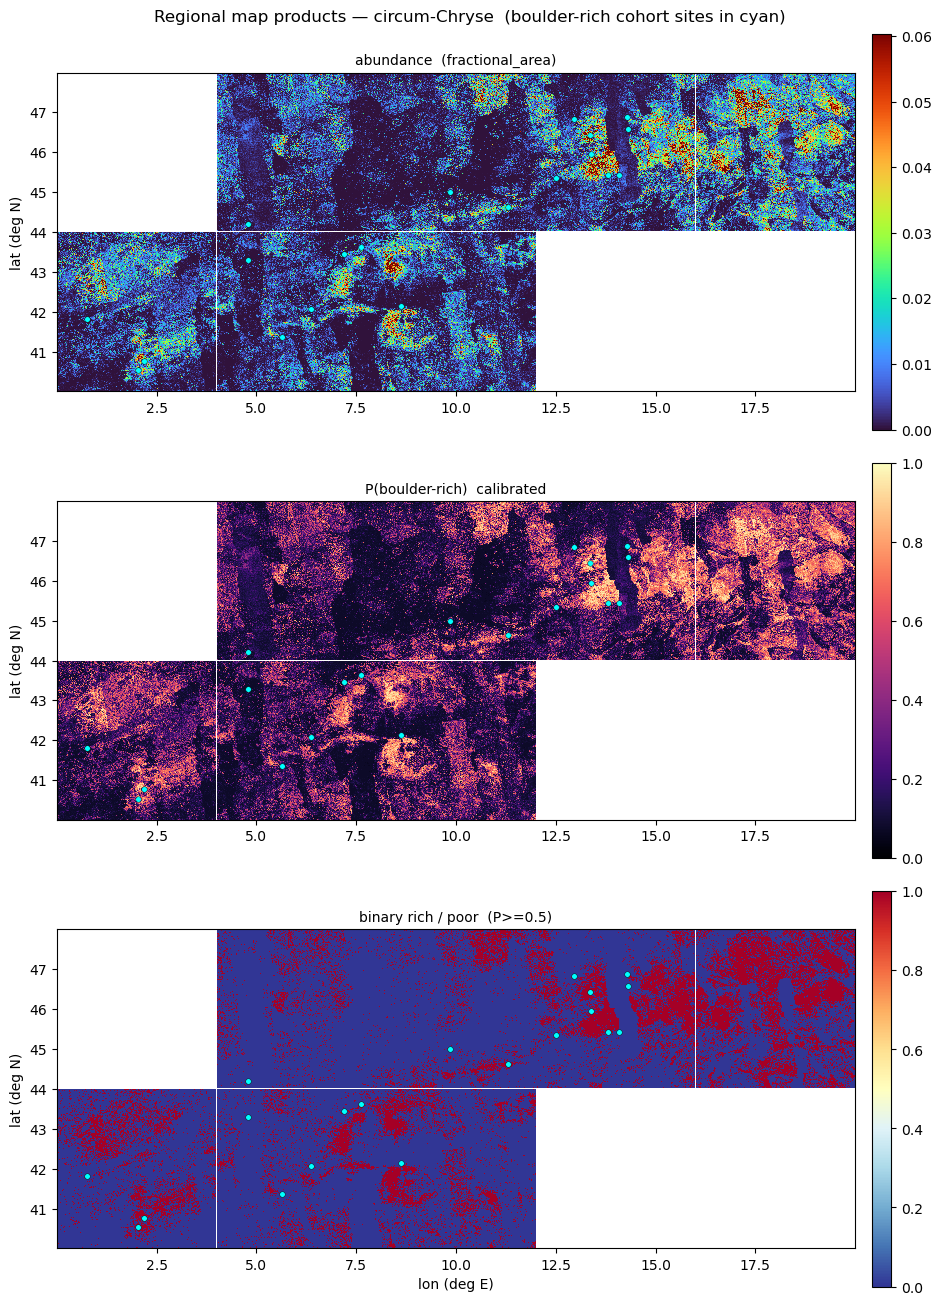

In [5]:
if ab_tifs:
    prob_arr, _, _ = mosaic_geotiffs(sorted(MAP_DIR.glob("*_prob.tif")),
                                     MAP_DIR / "regional_prob_mosaic.tif")
    binary = np.where(np.isfinite(prob_arr), (prob_arr >= 0.5).astype(float), np.nan)
    rich = in_block[in_block.BoulderLabel == "Boulder rich"]

    panels = [("abundance  (fractional_area)", arr,      "turbo",    0.0, vmax),
              ("P(boulder-rich)  calibrated", prob_arr,  "magma",    0.0, 1.0),
              ("binary rich / poor  (P>=0.5)", binary,   "RdYlBu_r", 0.0, 1.0)]
    fig, axes = plt.subplots(3, 1, figsize=(9.5, 13.5))   # vertical stack (region is wide)
    for ax, (title, data, cmap, vmin, vmx) in zip(axes, panels):
        im = ax.imshow(np.ma.masked_invalid(data), cmap=cmap, vmin=vmin, vmax=vmx, extent=ext,
                       origin="upper", aspect="equal", interpolation="nearest")
        ax.scatter(rich.CenterLon_180, rich.CenterLat, s=16, c="cyan", edgecolor="k",
                   lw=0.3, zorder=4)
        ax.set_xlim(ext[0], ext[1]); ax.set_ylim(ext[2], ext[3])
        ax.set_title(title, fontsize=10); ax.set_ylabel("lat (deg N)")
        fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
    axes[-1].set_xlabel("lon (deg E)")
    fig.suptitle("Regional map products — circum-Chryse  (boulder-rich cohort sites in cyan)",
                 fontsize=12)
    fig.tight_layout()
    out = FIG / "24_region_products.png"; fig.savefig(out, dpi=145, bbox_inches="tight")
    print("wrote", out.relative_to(REPO)); plt.show()

## 3. Validation legs *(to come — PLAN §2)*

1. **Spatial co-location** — abundance band ↔ THEMIS thermal-bright ↔ mapped contact.
2. **Thermal-inertia correlation** — rank-corr(abundance, TES TI), dust-masked.
3. **Shoreline-distance profile** — abundance vs distance from the −3795 m MOLA contour.
4. **Truth anchor** — predictions vs BoulderNet detections at `ESP_017355_2260`.
5. **Generalisation** — does the band continue along un-imaged boundary segments?

These require `src/thermal_retrieve.py` (PLAN phase 1) and the returned GeoTIFFs; they
land here as they are built.
